In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/wholesale_customers.csv')
print(df.shape)
df.describe()

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [4]:
from scipy.stats import skew

SPENDING_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

skewness = df[SPENDING_COLS].apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

Delicassen          11.113534
Frozen               5.887826
Milk                 4.039922
Detergents_Paper     3.619458
Grocery              3.575187
Fresh                2.552583
dtype: float64

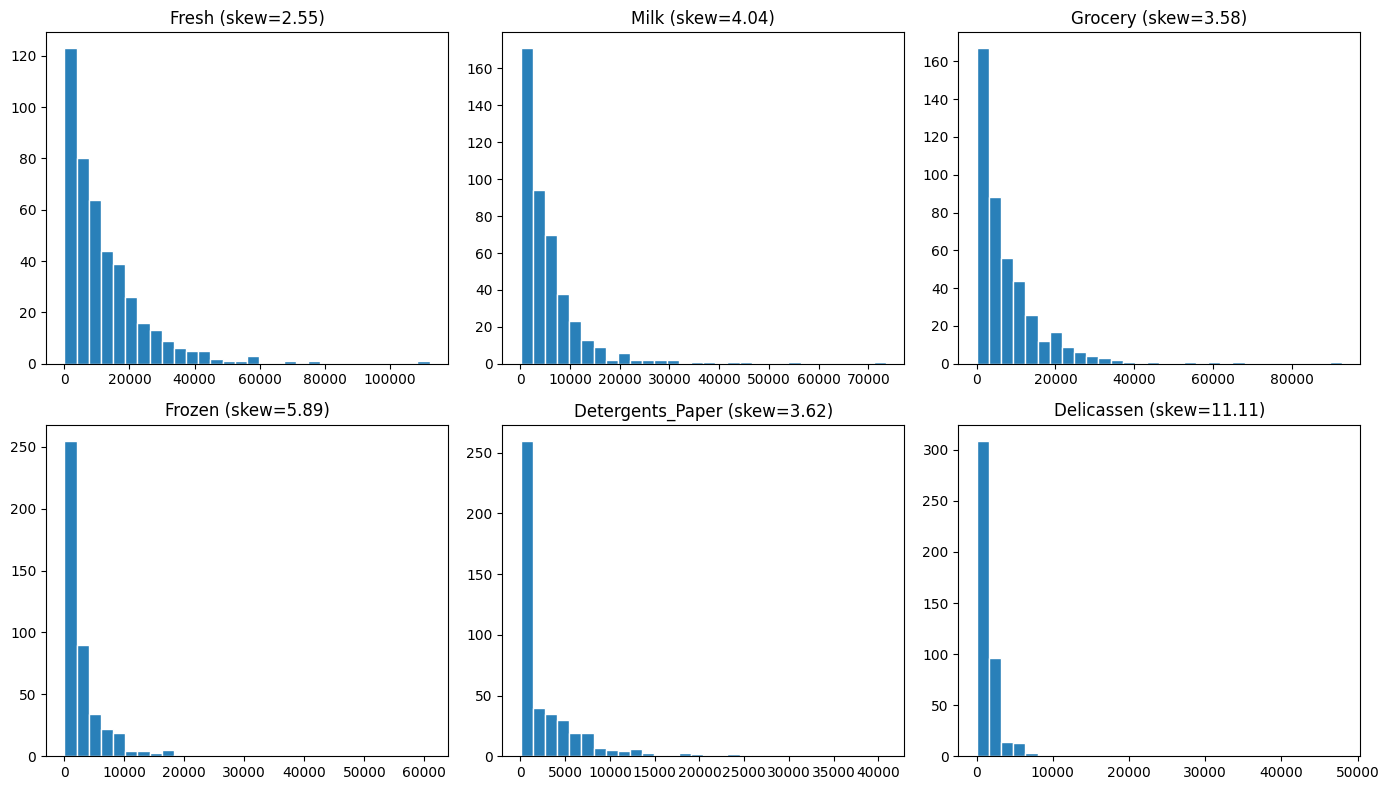

In [5]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_COLS):
    axes[i].hist(df[col], bins=30, color='#2980b9', edgecolor='white')
    axes[i].set_title(f'{col} (skew={skewness[col]:.2f})')
plt.tight_layout()
plt.savefig('../assets/01_raw_distributions_skew.png')
plt.show()

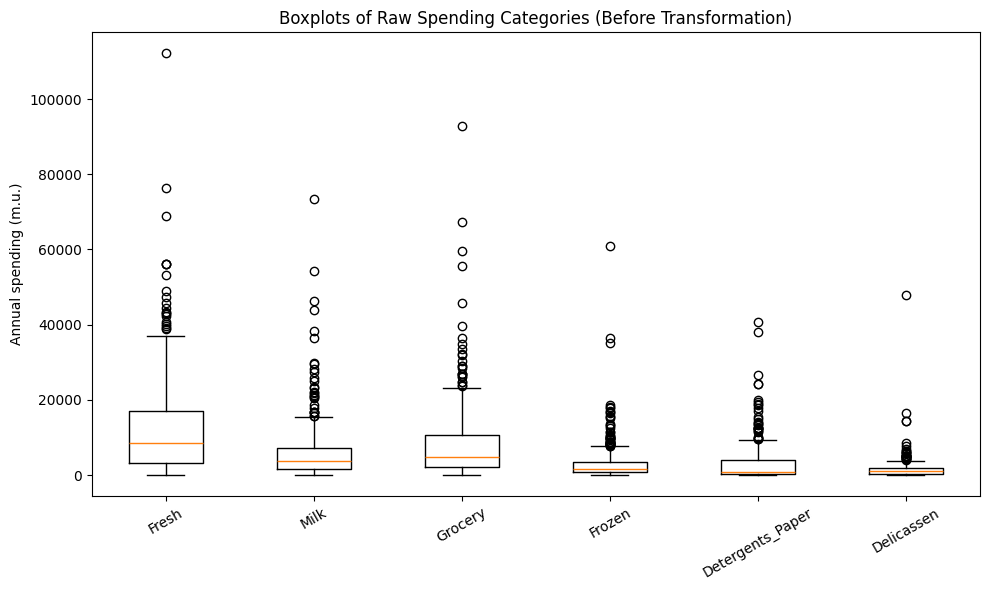

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([df[col] for col in SPENDING_COLS], tick_labels=SPENDING_COLS)
ax.set_title('Boxplots of Raw Spending Categories (Before Transformation)')
ax.set_ylabel('Annual spending (m.u.)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../assets/02_raw_boxplots_outliers.png')
plt.show()